<a href="https://colab.research.google.com/github/acedesci/scanalytics/blob/master/EN/S09_Retail_Analytics/SCA_Retail_demand_prediction_Local_vs_Global.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail analytics - Local versus Global Models
---
*Yossiri Adulyasak*

---

This is a pipeline to demonstrate the concept of local versus global models. In this demo, we will intentionally remove some data of an item-store at certain price points. Then, we will use both local and global models to try to predict the actual demands of the data that have been intentionally removed (hidden).

We begin by loading the required packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
# the algorithm below is sklearn implementation of LightGBM (not exactly the same but similar)
from sklearn.ensemble import HistGradientBoostingRegressor


## *Custom function - Error calculations

First, we create a function to measure the quality of predictions

In [2]:
def evaluate_model(model_name, y_true, y_pred):
    # MAE: Average absolute difference. Easy to interpret (e.g., "off by 20 units").
    mae = mean_absolute_error(y_true, y_pred)

    # RMSE: Root Mean Squared Error. Penalizes large errors more than MAE.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE: Mean Absolute Percentage Error. Shows error as a % of actual sales.
    # We use numpy (np) to calculate: mean( abs( (Actual - Pred) / Actual ) ) * 100
    mape = np.mean(np.abs((y_true - y_pred) / (y_true))) * 100

    # wMAPE: Weighted MAPE. Sum of Absolute Errors divided by the Sum of Actual Values
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

    # R2: How well the model explains the variance. 1.0 is perfect, 0.0 is useless.
    r2 = r2_score(y_true, y_pred)

    # Print the formatted results
    print(f"{model_name:18} | MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | MAPE: {mape:6.2f}% | wMAPE: {wmape:6.2f}% | R2: {r2:.4f}")

# Block 1: Data input

In [3]:
# Load data
URL = 'https://raw.githubusercontent.com/acedesci/scanalytics/refs/heads/master/EN/S08_09_Retail_Analytics/data/cereals_data_full.csv'
df = pd.read_csv(URL)
# Drop any rows that have missing values (NaN).
df = df.dropna()

# Calculate the discount column from 'BASE_PRICE' and 'PRICE'
df['DISCOUNT'] = (df['BASE_PRICE'] - df['PRICE']) / df['BASE_PRICE']

# Convert the 'WEEK_END_DATE' column from string format to a datetime object. This allows us to sort the data chronologically.
df['WEEK_END_DATE'] = pd.to_datetime(df['WEEK_END_DATE'])

# Extract Week Number (1-53) to capture seasonality
df['WEEK_NUM'] = df['WEEK_END_DATE'].dt.isocalendar().week.astype(int)

df

,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE,DISCOUNT,WEEK_NUM
0,2009-01-14,367,1111085319,14,13,13,26.32,1.88,1.88,0,0,0,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ,0.000000,3
1,2009-01-14,367,1111085345,29,26,25,54.52,1.88,1.88,0,0,0,PRIVATE LABEL,COLD CEREAL,ADULT CEREAL,18 OZ,0.000000,3
2,2009-01-14,367,1111085350,35,27,25,69.30,1.98,1.98,0,0,0,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.000000,3
3,2009-01-14,367,1600027527,12,10,10,38.28,3.19,3.19,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,12 OZ,0.000000,3
4,2009-01-14,367,1600027528,31,26,19,142.29,4.59,4.59,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138784,2012-01-04,29159,3800031838,48,43,39,157.92,3.29,3.29,0,0,0,KELLOGG,COLD CEREAL,KIDS CEREAL,15 OZ,0.000000,1
138785,2012-01-04,29159,3800039118,21,17,17,70.98,3.38,3.38,0,0,0,KELLOGG,COLD CEREAL,KIDS CEREAL,12 OZ,0.000000,1
138786,2012-01-04,29159,88491201426,32,29,23,105.92,3.31,3.31,0,0,0,POST FOODS,COLD CEREAL,ADULT CEREAL,18 OZ,0.000000,1
138787,2012-01-04,29159,88491201427,30,26,23,99.30,3.31,3.31,0,0,0,POST FOODS,COLD CEREAL,ADULT CEREAL,18 OZ,0.000000,1


# Block 2: Data preparation

We need to select the features and split the data. Here we will remove data of the selected store and item that is below a specific price cutoff (so that we can see how local versus global models would predict these data).

In [4]:
# Select a target Item-Store pair for demonstration
target_store, target_upc = 15541, 1600027528

# Mask for the target item at the target store
target_mask = (df['STORE_NUM'] == target_store) & (df['UPC'] == target_upc)
# Get all data for our target pair
item_store_df = df[target_mask].copy()

# Determine the price cutoff either based on a quantile or a given price
# price_cutoff = item_store_df['PRICE'].quantile(0.20)
price_cutoff = 4.00

print("remove data of store[",target_store,"], item[",target_upc,"] with price less than $", price_cutoff, "from training set")

# Training set for the local model (excluding prices below the cutoff)
train_local = item_store_df[item_store_df['PRICE'] >= price_cutoff]

# Training set for the global model (excluding prices below the cutoff)
# the data is *not* remove if one of these conditions is not true)
train_global = df[
    (df['STORE_NUM'] != target_store) |
    (df['UPC'] != target_upc) |
    (df['PRICE'] >= price_cutoff)
]

# Test set (only the low prices we hid from training)
test_set = item_store_df[item_store_df['PRICE'] < price_cutoff]

remove data of store[ 15541 ], item[ 1600027528 ] with price less than $ 4.0 from training set


In [5]:
train_local

,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE,DISCOUNT,WEEK_NUM
1035,2009-01-21,15541,1600027528,20,19,19,89.60,4.48,4.48,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,4
1726,2009-01-28,15541,1600027528,26,25,23,119.34,4.59,4.59,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,5
2418,2009-02-04,15541,1600027528,21,21,19,96.39,4.59,4.59,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,6
5827,2009-03-11,15541,1600027528,16,16,16,73.44,4.59,4.59,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,11
6512,2009-03-18,15541,1600027528,14,14,14,64.26,4.59,4.59,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134647,2011-12-07,15541,1600027528,15,15,15,71.85,4.79,4.79,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,49
135571,2011-12-14,15541,1600027528,11,11,11,52.69,4.79,4.79,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,50
136494,2011-12-21,15541,1600027528,12,12,12,57.48,4.79,4.79,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,51
137410,2011-12-28,15541,1600027528,14,12,12,67.06,4.79,4.79,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.0,52


# Block 3: Model & algorithm (training & testing)

In the next code cell, we train and test different types of models which include:


*   Linear regression using only price (Local Model)
*   Gradient boosting model on one item-store (Local Model)
*   Gradient boosting model on across all item-stores (Global Model)



In [6]:
# Model Training

# List of columns to exclude from the input features (X).
# - 'UNITS': This is the target, so we cannot use it to predict itself.
# - 'WEEK_END_DATE': The model doesn't understand dates directly, and we used it for splitting. We will use 'WEEK_NUM' instead.
# - 'SPEND', 'VISITS', 'HHS': These are "Data Leakage". They only exist *after* sales happen.
# - 'UPC' we want to demonstrate the attribute-based predictive model so that UPC is not directly used

# Define features to use (excluding UPC)
features = ['PRICE', 'BASE_PRICE','DISCOUNT', 'FEATURE', 'DISPLAY', 'TPR_ONLY', 'WEEK_NUM',
            'STORE_NUM', 'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']
# Identify the position of categorical features for the GBM model
# Encode categorical variables as 'category' (this works when using applicable models that support categorial variables)
cat_cols = ['FEATURE', 'DISPLAY', 'TPR_ONLY', 'WEEK_NUM', 'STORE_NUM',
            'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']

print("\n--- Model Comparison on Test Data ---")
# Initialize local linear model, train, predict and then evaluate
lr_local = LinearRegression()
lr_local.fit(train_local[['PRICE']], train_local['UNITS'])
pred_lr_local = lr_local.predict(test_set[['PRICE']])
evaluate_model("[Local linear regression]", test_set['UNITS'], pred_lr_local)

# Initialize the local GBM model, train, predict and then evaluate
gbm_local = HistGradientBoostingRegressor(categorical_features=cat_cols, random_state=0)
gbm_local.fit(train_local[features], train_local['UNITS'])
pred_gbm_local = gbm_local.predict(test_set[features])
evaluate_model("[Local GBM regression   ]", test_set['UNITS'], pred_gbm_local)

# Initialize the global GBM model, train, predict and then evaluate
gbm_global = HistGradientBoostingRegressor(categorical_features=cat_cols, random_state=0)
gbm_global.fit(train_global[features], train_global['UNITS'])
pred_gbm_global = gbm_global.predict(test_set[features])
evaluate_model("[Global GBM regression  ]", test_set['UNITS'], pred_gbm_global)



--- Model Comparison on Test Data ---
[Local linear regression] | MAE:  25.61 | RMSE:  37.18 | MAPE:  43.82% | wMAPE:  45.15% | R2: -0.0616
[Local GBM regression   ] | MAE:  39.02 | RMSE:  52.55 | MAPE:  56.73% | wMAPE:  68.81% | R2: -1.1208
[Global GBM regression  ] | MAE:  14.29 | RMSE:  18.24 | MAPE:  28.30% | wMAPE:  25.19% | R2: 0.7444


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


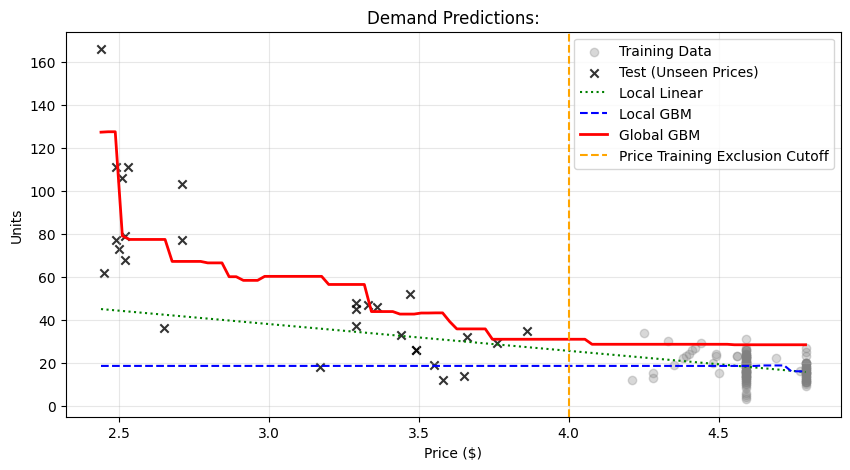

In [7]:
# Create a range of prices for the response curve plot
price_range = np.linspace(item_store_df['PRICE'].min(), item_store_df['PRICE'].max(), 100)
# print("Base price:", item_store_df['PRICE'].max())

discounts = (item_store_df['PRICE'].max() - price_range) / item_store_df['PRICE'].max()

# Create synthetic data to plot model curves
synthetic = pd.DataFrame({
    'PRICE': price_range.flatten(),
    'BASE_PRICE': item_store_df['PRICE'].max(),
    'DISCOUNT': discounts,
    'FEATURE': 1, 'DISPLAY': 0, 'TPR_ONLY': 0, 'WEEK_NUM': 52,
    'STORE_NUM': target_store,
    'MANUFACTURER': 'GENERAL MI',
    'CATEGORY': 'COLD CEREAL',
    'SUB_CATEGORY': 'ALL FAMILY CEREAL',
    'PRODUCT_SIZE': '18 OZ'
})

# Generate plot
plt.figure(figsize=(10, 5))
plt.scatter(train_local['PRICE'], train_local['UNITS'], color='gray', alpha=0.3, label='Training Data')
plt.scatter(test_set['PRICE'], test_set['UNITS'], color='black', alpha=0.8, marker='x', label='Test (Unseen Prices)')
plt.plot(price_range, lr_local.predict(price_range.reshape(-1, 1)), 'g:', label='Local Linear')
plt.plot(price_range, gbm_local.predict(synthetic[features]), 'b--', label='Local GBM')
plt.plot(price_range, gbm_global.predict(synthetic[features]), 'r-', linewidth=2, label='Global GBM')
plt.axvline(price_cutoff, color='orange', linestyle='--', label='Price Training Exclusion Cutoff')
plt.title('Demand Predictions:')
plt.xlabel('Price ($)')
plt.ylabel('Units')
plt.legend()
plt.grid(True, alpha=0.3)